In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


In [11]:
import pandas as pd
import numpy as np

print("="*60)
print("DOWNLOADING FRESH UCI HEART DISEASE DATASET")
print("="*60)

# Download directly from UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for the Cleveland dataset
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

try:
    # Download the dataset
    df = pd.read_csv(url, names=column_names, na_values='?')
    
    print(f"\n✓ Successfully downloaded!")
    print(f"  Shape: {df.shape}")
    
    # Verify the data IMMEDIATELY
    print(f"\n✓ Verification BEFORE any processing:")
    print(f"  sex column - unique values: {df['sex'].unique()}")
    print(f"  sex column - counts:\n{df['sex'].value_counts()}")
    print(f"  cp column - unique values: {df['cp'].unique()}")
    print(f"  cp column - counts:\n{df['cp'].value_counts()}")
    
    # Save the ORIGINAL downloaded file
    df.to_csv('heart_disease_uci_original.csv', index=False)
    print(f"\n✓ Saved original as: heart_disease_uci_original.csv")
    
    # =================================================================
    # NOW CLEAN IT PROPERLY
    # =================================================================
    print(f"\n" + "="*60)
    print("CLEANING THE DATA")
    print("="*60)
    
    df_clean = df.copy()
    
    # Fill missing values in SPECIFIC columns only
    # Don't touch sex and cp!
    fill_cols = {
        'age': df_clean['age'].median(),
        'trestbps': df_clean['trestbps'].median(),
        'chol': df_clean['chol'].median(),
        'thalach': df_clean['thalach'].median(),
        'oldpeak': df_clean['oldpeak'].median(),
        'ca': 0.0,  # Most common value
        'thal': 3.0  # Most common value
    }
    
    for col, fill_val in fill_cols.items():
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            before = df_clean[col].isnull().sum()
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"  {col}: filled {before} NaN → {fill_val}")
    
    # Remove duplicates
    df_clean.drop_duplicates(inplace=True)
    
    # Create target variable
    df_clean['target'] = df_clean['num'].apply(lambda x: 0 if x == 0 else 1)
    
    # Create labels
    df_clean['target_label'] = df_clean['target'].map({0: 'No Disease', 1: 'Disease'})
    df_clean['sex_label'] = df_clean['sex'].map({0: 'Female', 1: 'Male'})
    df_clean['cp_label'] = df_clean['cp'].map({
        1: 'Typical Angina',
        2: 'Atypical Angina',
        3: 'Non-anginal',
        4: 'Asymptomatic'
    })
    
    # Additional derived columns
    df_clean['age_group'] = pd.cut(df_clean['age'], 
                                    bins=[0, 40, 50, 60, 70, 100],
                                    labels=['<40', '40-50', '50-60', '60-70', '>70'])
    df_clean['chol_category'] = pd.cut(df_clean['chol'], 
                                        bins=[0, 200, 240, 500],
                                        labels=['Normal', 'Borderline High', 'High'])
    df_clean['exang_label'] = df_clean['exang'].map({0: 'No Exercise Angina', 
                                                      1: 'Exercise Angina'})
    
    # Save cleaned data
    df_clean.to_csv('heart_disease_cleaned.csv', index=False)
    
    print(f"\n✓ CLEANING COMPLETED!")
    print(f"  Final shape: {df_clean.shape}")
    
    # =================================================================
    # FINAL VERIFICATION
    # =================================================================
    print(f"\n" + "="*60)
    print("FINAL VERIFICATION")
    print("="*60)
    
    print(f"\nsex and sex_label:")
    print(f"  sex unique: {df_clean['sex'].unique()}")
    print(f"  sex_label counts:\n{df_clean['sex_label'].value_counts()}")
    
    print(f"\ncp and cp_label:")
    print(f"  cp unique: {df_clean['cp'].unique()}")
    print(f"  cp_label counts:\n{df_clean['cp_label'].value_counts()}")
    
    print(f"\ntarget_label:")
    print(f"  {df_clean['target_label'].value_counts()}")
    
    print(f"\nSample of cleaned data:")
    print(df_clean[['age', 'sex', 'sex_label', 'cp', 'cp_label', 
                    'target', 'target_label']].head(10))
    
    print(f"\n" + "="*60)
    print("✓✓✓ SUCCESS! DATA IS READY FOR VISUALIZATION ✓✓✓")
    print("="*60)
    
except Exception as e:
    print(f"\n✗ Error downloading: {e}")
    print("\nAlternative: Download manually from Kaggle")
    print("URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data")


DOWNLOADING FRESH UCI HEART DISEASE DATASET

✓ Successfully downloaded!
  Shape: (303, 14)

✓ Verification BEFORE any processing:
  sex column - unique values: [1. 0.]
  sex column - counts:
sex
1.0    206
0.0     97
Name: count, dtype: int64
  cp column - unique values: [1. 4. 3. 2.]
  cp column - counts:
cp
4.0    144
3.0     86
2.0     50
1.0     23
Name: count, dtype: int64

✓ Saved original as: heart_disease_uci_original.csv

CLEANING THE DATA
  ca: filled 4 NaN → 0.0
  thal: filled 2 NaN → 3.0

✓ CLEANING COMPLETED!
  Final shape: (303, 21)

FINAL VERIFICATION

sex and sex_label:
  sex unique: [1. 0.]
  sex_label counts:
sex_label
Male      206
Female     97
Name: count, dtype: int64

cp and cp_label:
  cp unique: [1. 4. 3. 2.]
  cp_label counts:
cp_label
Asymptomatic       144
Non-anginal         86
Atypical Angina     50
Typical Angina      23
Name: count, dtype: int64

target_label:
  target_label
No Disease    164
Disease       139
Name: count, dtype: int64

Sample of cleaned

CREATING ALL EDA VISUALIZATIONS
Dataset: 303 rows

1. Creating target distribution...


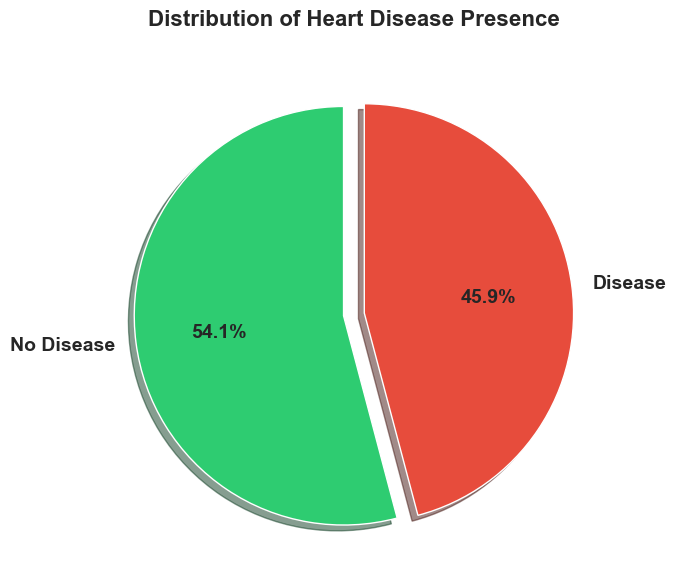

   ✓ Saved: eda_01_target_distribution.png
   Disease: 139 (45.9%)
   No Disease: 164 (54.1%)



In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load cleaned data
df = pd.read_csv('heart_disease_cleaned.csv')

print("="*60)
print("CREATING ALL EDA VISUALIZATIONS")
print("="*60)
print(f"Dataset: {len(df)} rows\n")

# =================================================================
# VISUALIZATION 1: TARGET DISTRIBUTION
# =================================================================
print("1. Creating target distribution...")

plt.figure(figsize=(10, 6))
target_counts = df['target_label'].value_counts()
colors = ['#2ECC71', '#E74C3C']

plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, 
        textprops={'fontsize': 14, 'fontweight': 'bold'},
        explode=(0.05, 0.05), shadow=True)
plt.title('Distribution of Heart Disease Presence', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_01_target_distribution.png")
print(f"   Disease: {(df['target']==1).sum()} ({(df['target']==1).sum()/len(df)*100:.1f}%)")
print(f"   No Disease: {(df['target']==0).sum()} ({(df['target']==0).sum()/len(df)*100:.1f}%)\n")


2. Creating age distribution...


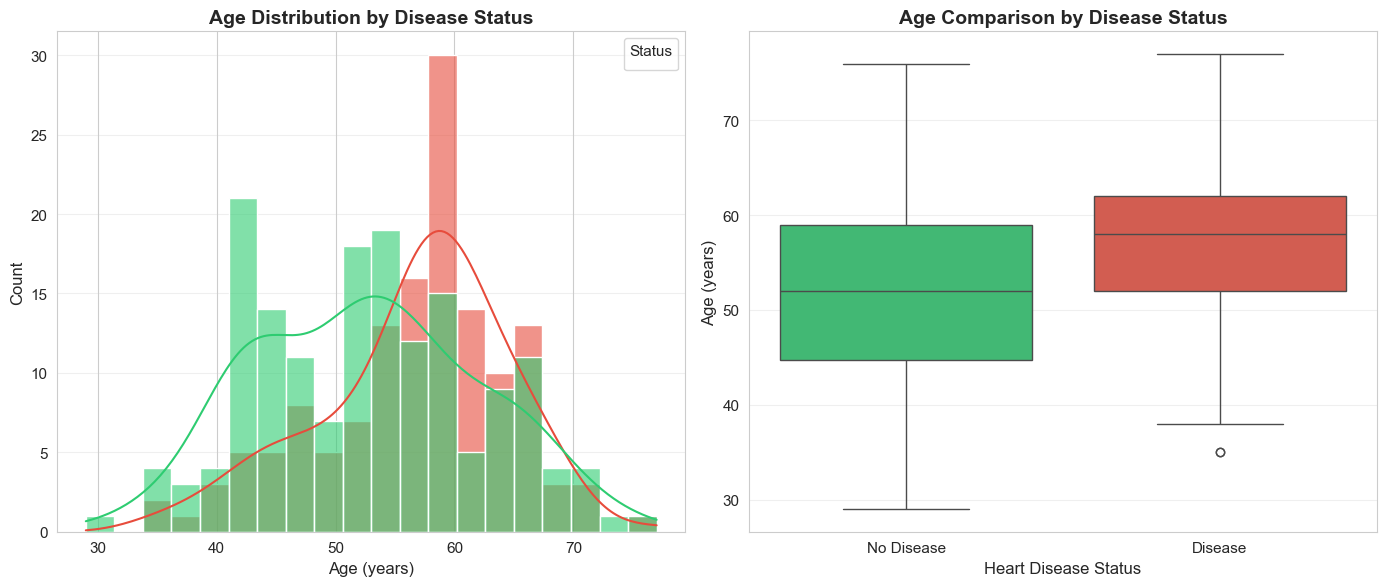

   ✓ Saved: eda_02_age_analysis.png
   Disease - Mean Age: 56.6 years
   No Disease - Mean Age: 52.6 years



In [18]:
# =================================================================
# VISUALIZATION 2: AGE DISTRIBUTION
# =================================================================
print("2. Creating age distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='age', hue='target_label', kde=True, 
             bins=20, palette=['#2ECC71', '#E74C3C'], alpha=0.6, ax=axes[0])
axes[0].set_title('Age Distribution by Disease Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='Status', fontsize=10)

# Boxplot
sns.boxplot(data=df, x='target_label', y='age', 
            palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Age Comparison by Disease Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Heart Disease Status', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_02_age_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_02_age_analysis.png")
print(f"   Disease - Mean Age: {df[df['target']==1]['age'].mean():.1f} years")
print(f"   No Disease - Mean Age: {df[df['target']==0]['age'].mean():.1f} years\n")


3. Creating gender analysis...


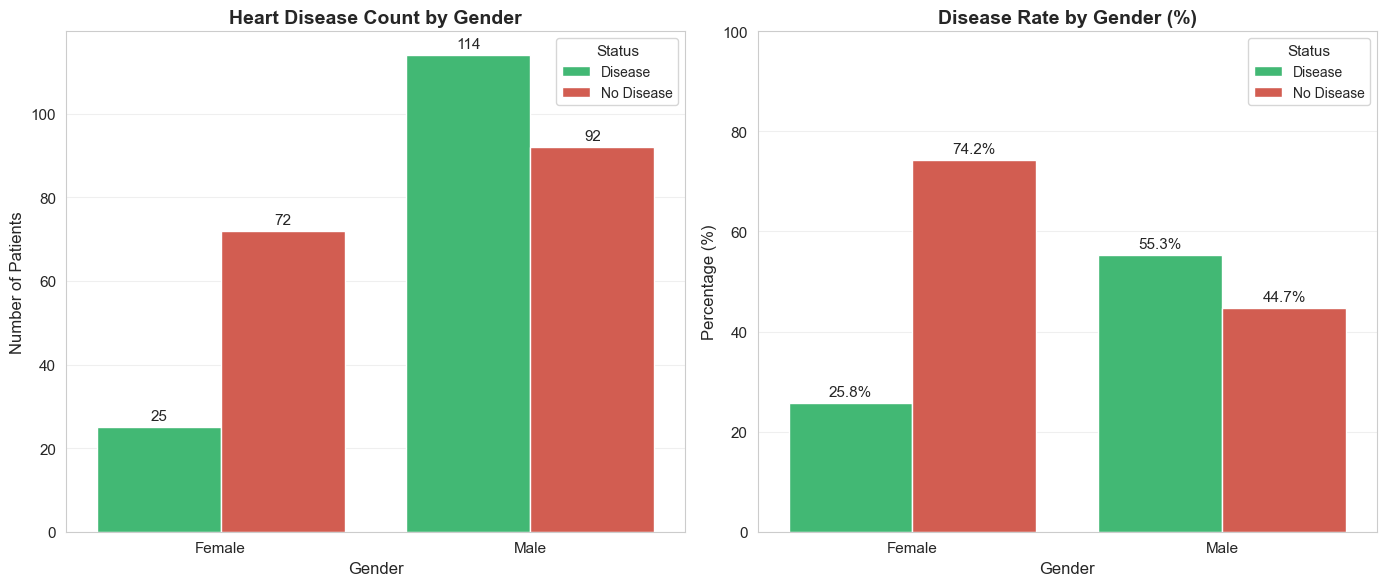

   ✓ Saved: eda_03_gender_analysis.png
   target_label  Disease  No Disease
sex_label                        
Female             25          72
Male              114          92



In [20]:
# =================================================================
# VISUALIZATION 3: GENDER ANALYSIS
# =================================================================
print("3. Creating gender analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute counts
gender_data = df.groupby(['sex_label', 'target_label']).size().reset_index(name='count')
sns.barplot(data=gender_data, x='sex_label', y='count', hue='target_label',
            palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Heart Disease Count by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].legend(title='Status', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3)

# Percentages
gender_pct = pd.crosstab(df['sex_label'], df['target_label'], normalize='index') * 100
gender_pct_data = gender_pct.reset_index().melt(id_vars='sex_label',
                                                 var_name='target_label',
                                                 value_name='percentage')
sns.barplot(data=gender_pct_data, x='sex_label', y='percentage', hue='target_label',
            palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Disease Rate by Gender (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Status', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 100)

# Add percentage labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig('eda_03_gender_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_03_gender_analysis.png")
gender_stats = pd.crosstab(df['sex_label'], df['target_label'])
print(f"   {gender_stats}\n")


4. Creating chest pain analysis...


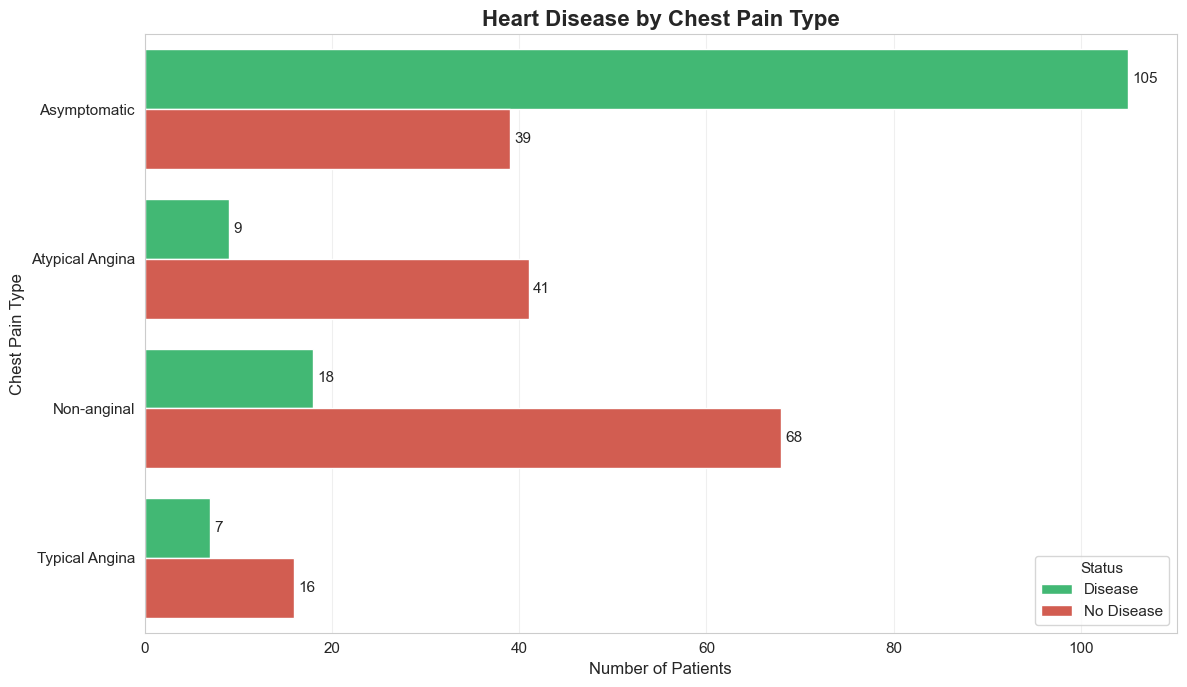

   ✓ Saved: eda_04_chest_pain_analysis.png
   target_label     Disease  No Disease
cp_label                            
Asymptomatic         105          39
Atypical Angina        9          41
Non-anginal           18          68
Typical Angina         7          16



In [22]:
# =================================================================
# VISUALIZATION 4: CHEST PAIN TYPE ANALYSIS
# =================================================================
print("4. Creating chest pain analysis...")

plt.figure(figsize=(12, 7))

cp_data = df.groupby(['cp_label', 'target_label']).size().reset_index(name='count')
sns.barplot(data=cp_data, y='cp_label', x='count', hue='target_label',
            palette=['#2ECC71', '#E74C3C'], orient='h')

plt.title('Heart Disease by Chest Pain Type', fontsize=16, fontweight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Chest Pain Type', fontsize=12)
plt.legend(title='Status', fontsize=11, loc='best')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig('eda_04_chest_pain_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_04_chest_pain_analysis.png")
cp_stats = pd.crosstab(df['cp_label'], df['target_label'])
print(f"   {cp_stats}\n")


5. Creating cholesterol analysis...


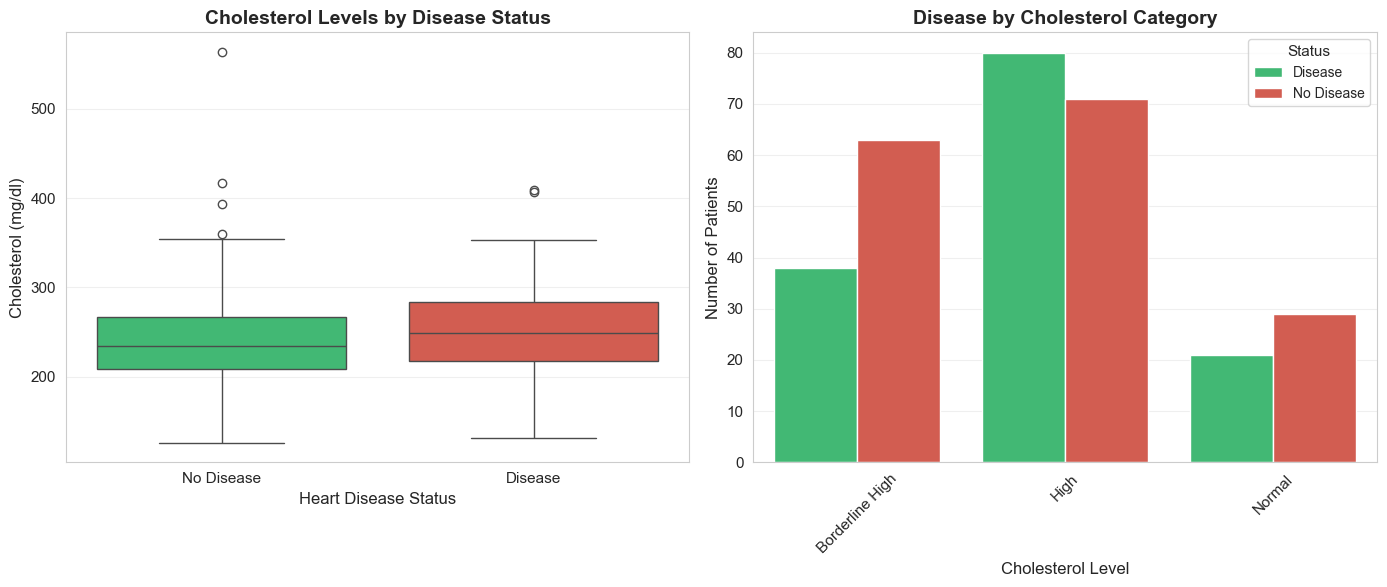

   ✓ Saved: eda_05_cholesterol_analysis.png
   Disease - Mean: 251.5 mg/dl
   No Disease - Mean: 242.6 mg/dl



In [24]:
# =================================================================
# VISUALIZATION 5: CHOLESTEROL ANALYSIS
# =================================================================
print("5. Creating cholesterol analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(data=df, x='target_label', y='chol',
            palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Cholesterol Levels by Disease Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Status', fontsize=12)
axes[0].set_ylabel('Cholesterol (mg/dl)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Category bars
chol_data = df.groupby(['chol_category', 'target_label']).size().reset_index(name='count')
sns.barplot(data=chol_data, x='chol_category', y='count', hue='target_label',
            palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Disease by Cholesterol Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cholesterol Level', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='Status', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_05_cholesterol_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_05_cholesterol_analysis.png")
print(f"   Disease - Mean: {df[df['target']==1]['chol'].mean():.1f} mg/dl")
print(f"   No Disease - Mean: {df[df['target']==0]['chol'].mean():.1f} mg/dl\n")


6. Creating heart rate analysis...


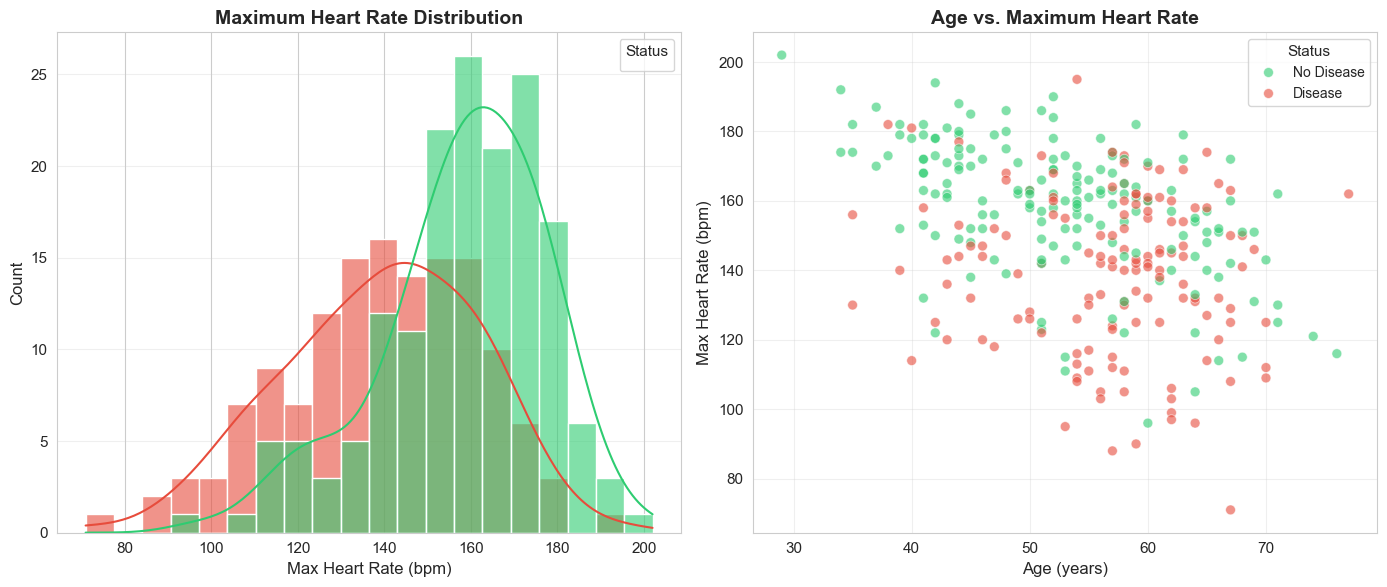

   ✓ Saved: eda_06_heart_rate_analysis.png
   Disease - Mean: 139.3 bpm
   No Disease - Mean: 158.4 bpm



In [26]:
# =================================================================
# VISUALIZATION 6: MAXIMUM HEART RATE ANALYSIS
# =================================================================
print("6. Creating heart rate analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
sns.histplot(data=df, x='thalach', hue='target_label', kde=True,
             bins=20, palette=['#2ECC71', '#E74C3C'], alpha=0.6, ax=axes[0])
axes[0].set_title('Maximum Heart Rate Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Max Heart Rate (bpm)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='Status', fontsize=10)

# Scatter plot
sns.scatterplot(data=df, x='age', y='thalach', hue='target_label',
                palette=['#2ECC71', '#E74C3C'], alpha=0.6, s=50, ax=axes[1])
axes[1].set_title('Age vs. Maximum Heart Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age (years)', fontsize=12)
axes[1].set_ylabel('Max Heart Rate (bpm)', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend(title='Status', fontsize=10)

plt.tight_layout()
plt.savefig('eda_06_heart_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_06_heart_rate_analysis.png")
print(f"   Disease - Mean: {df[df['target']==1]['thalach'].mean():.1f} bpm")
print(f"   No Disease - Mean: {df[df['target']==0]['thalach'].mean():.1f} bpm\n")


7. Creating correlation heatmap...


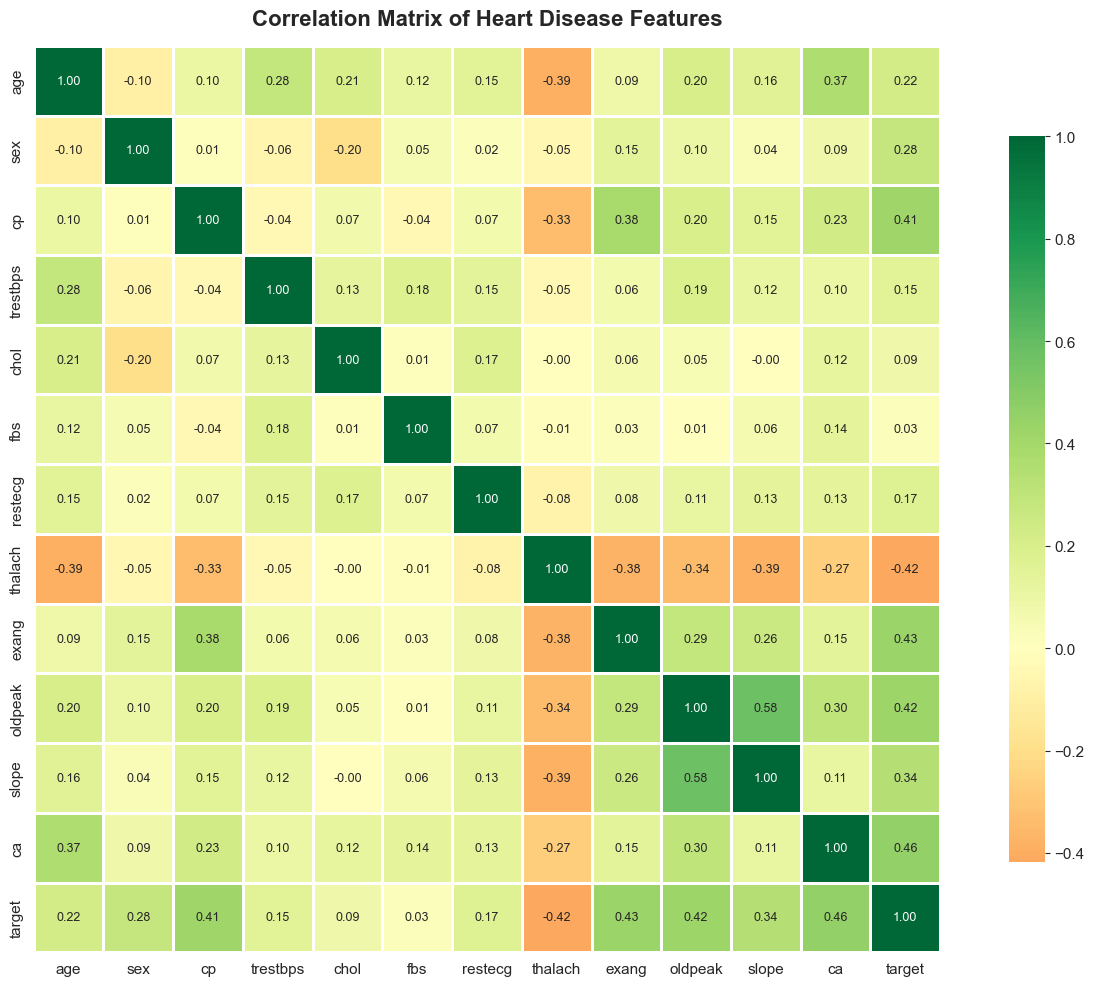

   ✓ Saved: eda_07_correlation_heatmap.png

   Top 5 Features Correlated with Heart Disease:
target     1.000000
ca         0.460033
exang      0.431894
oldpeak    0.424510
thalach    0.417167
cp         0.414446
Name: target, dtype: float64 



In [28]:
# =================================================================
# VISUALIZATION 7: CORRELATION HEATMAP
# =================================================================
print("7. Creating correlation heatmap...")

plt.figure(figsize=(14, 10))

numeric_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target']

# Select only existing columns
numeric_cols = [col for col in numeric_features if col in df.columns]
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, 
            fmt='.2f', annot_kws={'size': 9})
plt.title('Correlation Matrix of Heart Disease Features', 
          fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_07_correlation_heatmap.png")
print(f"\n   Top 5 Features Correlated with Heart Disease:")
correlations = correlation_matrix['target'].abs().sort_values(ascending=False)
print(correlations.head(6), "\n")  # Top 6 (including target itself)


8. Creating exercise-induced angina analysis...


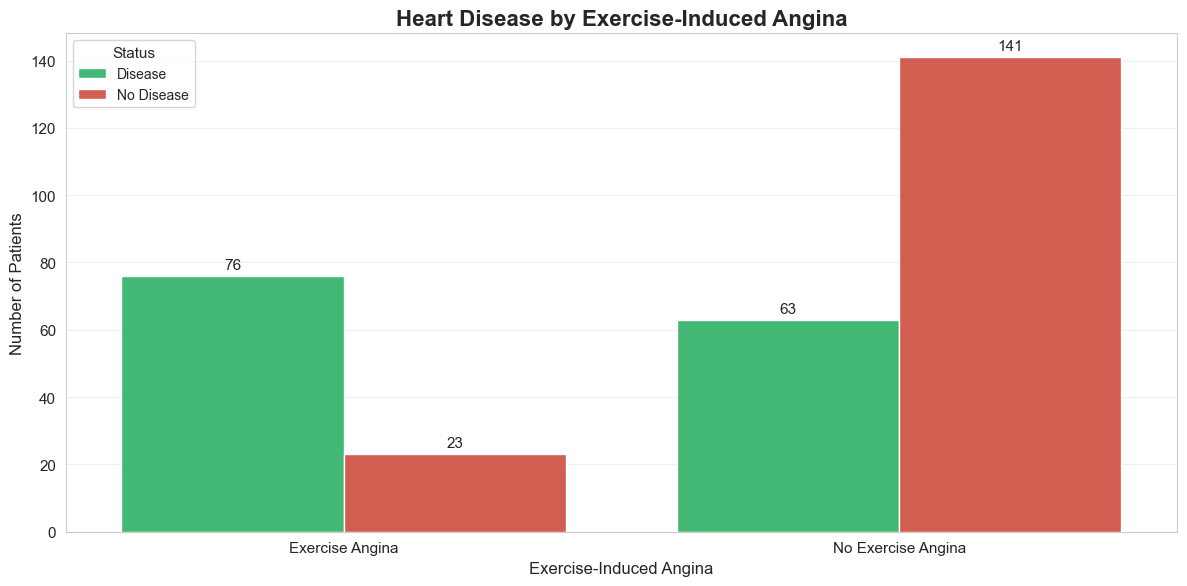

   ✓ Saved: eda_08_exercise_angina.png
target_label        Disease  No Disease
exang_label                            
Exercise Angina          76          23
No Exercise Angina       63         141


In [32]:
# =================================================================
# VISUALIZATION 8: EXERCISE-INDUCED ANGINA ANALYSIS
# =================================================================
print("8. Creating exercise-induced angina analysis...")

plt.figure(figsize=(12, 6))

exang_data = df.groupby(['exang_label', 'target_label']).size().reset_index(name='count')
sns.barplot(data=exang_data, x='exang_label', y='count', hue='target_label',
            palette=['#2ECC71', '#E74C3C'])

plt.title('Heart Disease by Exercise-Induced Angina', fontsize=16, fontweight='bold')
plt.xlabel('Exercise-Induced Angina', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig('eda_08_exercise_angina.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✓ Saved: eda_08_exercise_angina.png")
exang_stats = pd.crosstab(df['exang_label'], df['target_label'])
print(f"{exang_stats}")
